Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [27]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Católica\IA\Clinical-database\FDC_Low_Dimension\Jupyter Notebooks
Diretório pai adicionado: c:\Católica\IA\Clinical-database\FDC_Low_Dimension


In [28]:
import subprocess
import sys, os
sys.path.insert(0, os.path.abspath('../../FDC_Intermediate_Dimension'))

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
import umap.umap_ as umap
%config InlineBackend.figure_format = 'svg'

In [30]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

In [31]:
from cluster_val import *

Importando os dados

In [32]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data=pd.read_csv('../Datasets/cirrhosis.csv',index_col='ID')

In [33]:
np.random.seed(42)
data=data.sample(frac=1) #Shuffle the data set
np.random.seed(42)
i=[x for x in range(418)]

data.set_index(pd.Series(i), inplace=True)

Pré-processamento

In [34]:
data.isna().sum()

N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [35]:
data['Status'].value_counts()

Status
C     232
D     161
CL     25
Name: count, dtype: int64

In [36]:
Status_mod= {'Status': {'C':0,'D':1,'CL':2}}
data.replace(Status_mod,inplace=True)
data['Status']

0      1
1      0
2      0
3      1
4      1
      ..
413    0
414    0
415    0
416    0
417    1
Name: Status, Length: 418, dtype: int64

In [37]:
data['Drug'].value_counts()

Drug
D-penicillamine    158
Placebo            154
Name: count, dtype: int64

In [38]:
Drug_mod= {'Drug':{'D-penicillamine':0,'Placebo':1}}
data.replace(Drug_mod,inplace=True)
data['Drug']

0      NaN
1      NaN
2      NaN
3      0.0
4      0.0
      ... 
413    1.0
414    1.0
415    1.0
416    NaN
417    1.0
Name: Drug, Length: 418, dtype: float64

In [39]:
data['Sex'].value_counts()

Sex
F    374
M     44
Name: count, dtype: int64

In [40]:
Sex_mod= {'Sex':{'F':0,'M':1}}
data.replace(Sex_mod,inplace=True)
data['Sex']

0      0
1      0
2      0
3      0
4      1
      ..
413    0
414    0
415    0
416    0
417    0
Name: Sex, Length: 418, dtype: int64

In [41]:
data['Ascites'].value_counts()

Ascites
N    288
Y     24
Name: count, dtype: int64

In [42]:
Ascites_mod= {'Ascites':{'N':0,'Y':1}}
data.replace(Ascites_mod,inplace=True)
data['Ascites']

0      NaN
1      NaN
2      NaN
3      0.0
4      0.0
      ... 
413    0.0
414    0.0
415    0.0
416    NaN
417    1.0
Name: Ascites, Length: 418, dtype: float64

In [43]:
data['Hepatomegaly'].value_counts()

Hepatomegaly
Y    160
N    152
Name: count, dtype: int64

In [44]:
Hepatomegaly_mod= {'Hepatomegaly':{'N':0,'Y':1}}
data.replace(Hepatomegaly_mod,inplace=True)
data['Hepatomegaly']

0      NaN
1      NaN
2      NaN
3      1.0
4      0.0
      ... 
413    0.0
414    0.0
415    1.0
416    NaN
417    1.0
Name: Hepatomegaly, Length: 418, dtype: float64

In [45]:
data['Spiders'].value_counts()

Spiders
N    222
Y     90
Name: count, dtype: int64

In [46]:
Spiders_mod= {'Spiders':{'N':0,'Y':1}}
data.replace(Spiders_mod,inplace=True)
data['Spiders']

0      NaN
1      NaN
2      NaN
3      0.0
4      1.0
      ... 
413    0.0
414    0.0
415    0.0
416    NaN
417    1.0
Name: Spiders, Length: 418, dtype: float64

In [47]:
data['Edema'].value_counts()

Edema
N    354
S     44
Y     20
Name: count, dtype: int64

In [48]:
Edema_mod= {'Edema':{'N':0,'S':1,'Y':2}}
data.replace(Edema_mod,inplace=True)
data['Edema']

0      0
1      0
2      0
3      1
4      2
      ..
413    0
414    0
415    0
416    0
417    2
Name: Edema, Length: 418, dtype: int64

Colocando valores faltando

In [49]:
dense_data_pool=list(data.isna().sum().index[data.isna().sum()<1])
dense_data=data[dense_data_pool]
dense_data=dense_data.dropna()
data=data.loc[np.array(dense_data.index)]

In [50]:
from scipy.spatial import distance
distance_matrix=[]
for i in range(len(np.array(dense_data))):
    dist=[]
    for j in range(len(np.array(dense_data))):
        d=distance.euclidean(np.array(dense_data)[i],np.array(dense_data)[j])
        dist.append(d)
        neb_list=np.array(dense_data.index)[np.argsort(dist)]
    distance_matrix.append(neb_list)
distance_matrix=np.array(distance_matrix)

In [51]:
missing_value_list = [x for x in list(data.columns) if x not in dense_data_pool]

In [52]:
total_impute_master=[]
for f in range(len(missing_value_list)):
    missing_value_indices=data[data[missing_value_list[f]].isnull()].index.tolist()
    feature_impute_master=[]
    for index in missing_value_indices:
        index_in_dist_mat=np.where(distance_matrix[:,0]==index)[0][0]
        value_list=[]
        neb_index_counter=1
        while len(value_list)<6:
            neb_index=distance_matrix[index_in_dist_mat][neb_index_counter]
            neb_index_counter=neb_index_counter+1
            impute_value=data.loc[[neb_index]][missing_value_list[f]]
            if float(impute_value)!=float(impute_value):
                pass
            else:
                value_list.append(float(impute_value))
        feature_impute_master.append(np.array(value_list))
    total_impute_master.append(np.array(feature_impute_master))
# total_impute_mater=np.array(total_impute_master)


In [53]:
total_impute=[]
for i in range(len(total_impute_master)):
    feature_impute=[]
    for j in range(len(total_impute_master[i])):
        intcounter=0
        for k in range(len(total_impute_master[i][j])):
            if total_impute_master[i][j][k]-int(total_impute_master[i][j][k])==0:
                intcounter=intcounter+1
        if intcounter==len(total_impute_master[i][j]):
            imputed_value=np.bincount(total_impute_master[i][j].astype(int)).argmax()
        else:
            imputed_value=np.mean(total_impute_master[i][j])
        feature_impute.append(np.array(imputed_value))
    total_impute.append(np.array(feature_impute))
    

In [54]:
for f in range(len(missing_value_list)):
    missing_value_indices=data[data[missing_value_list[f]].isnull()].index.tolist()
    for i in range(len(missing_value_indices)):
        data.at[missing_value_indices[i], missing_value_list[f]]=total_impute[f][i]

In [55]:
data.isna().sum()

N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

In [56]:
data=data.drop(['Stage'], axis=1)


In [57]:
data.shape

(418, 18)

UMAP nos dados originais

In [58]:
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
from fdc.clustering import *
modified_can = canberra_modified

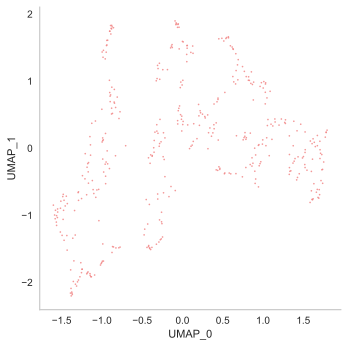

In [59]:
umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering K-means

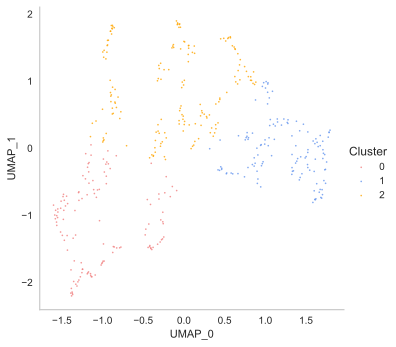

In [60]:
umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(3)

In [61]:
cont_list= ['N_Days','Age','Bilirubin','Cholesterol','Albumin','Copper','Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin']

ord_list= ['Ascites','Hepatomegaly','Spiders','Edema']

nom_list= ['Status','Drug','Sex']

In [62]:


### ANOVA TEST


data['Cluster']=umap_cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  61.11 %
percentage of ordinal features having p-value less than 0.05:  75.0 %
percentage of  nominal features having p-value less than 0.05:  66.66666666666666 %
percentage of continous features having p-value less than 0.05:  54.54545454545454 %


In [63]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.5808206731661105

Visualizar Silhouette score (Pode-se escolher o números de clusters baseados no resultado)

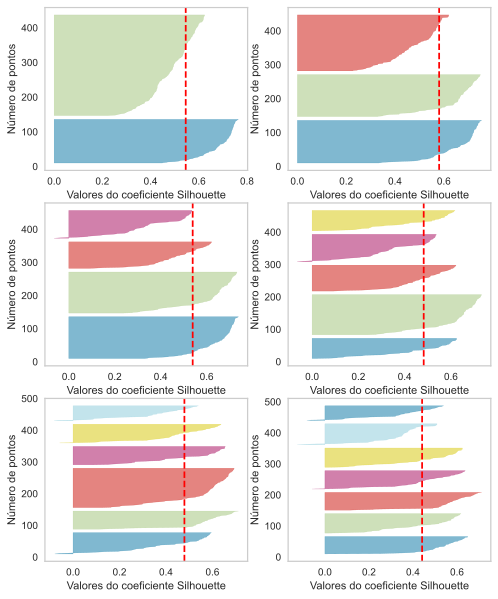

In [64]:
Silhouette_visual(umap_emb)

Elbow plot para umap_embedding

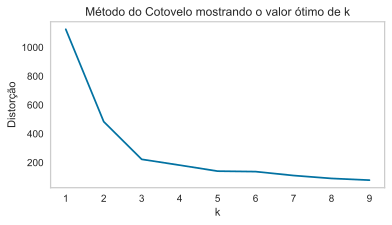

In [65]:
elbow_plot(umap_emb)

In [66]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.04248972079886398

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering Aglomerativo

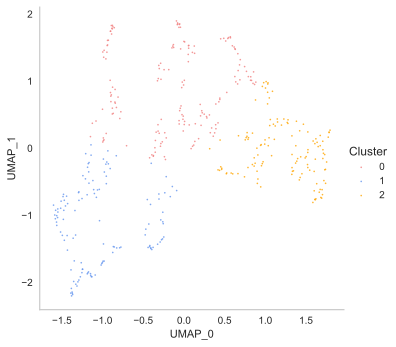

In [67]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(3,'euclidean','ward')

In [68]:


### ANOVA TEST


data['Cluster']=umap_cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  61.11 %
percentage of ordinal features having p-value less than 0.05:  75.0 %
percentage of  nominal features having p-value less than 0.05:  66.66666666666666 %
percentage of continous features having p-value less than 0.05:  54.54545454545454 %


In [69]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.6190841330346963

In [70]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.03714608010911571

ANOVA test, Silhouette_score e Dunn index para os clusters do UMAP extraidos usando clustering DBSCAN 

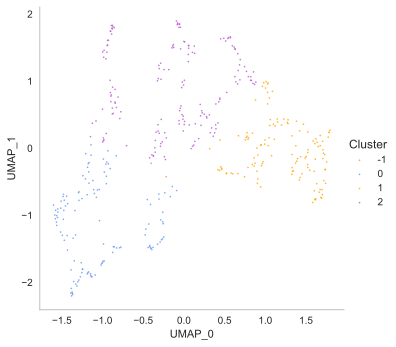

In [71]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.5,20)

In [72]:

### ANOVA TEST

data['Cluster']=umap_cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))-1):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  61.11 %
percentage of ordinal features having p-value less than 0.05:  75.0 %
percentage of  nominal features having p-value less than 0.05:  66.66666666666666 %
percentage of continous features having p-value less than 0.05:  54.54545454545454 %


In [73]:
#removing noise indices from the embeddings
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]


In [74]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.5823256052393133

In [75]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.04248972079886398

Dividindo as variaveis
- cont_list = continuas
- ord_list = ordinais
-  nom_list  = nominais

In [76]:
cont_list= ['N_Days','Age','Bilirubin','Cholesterol','Albumin','Copper','Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin']

ord_list= ['Ascites','Hepatomegaly','Spiders','Edema']

nom_list= ['Status','Drug','Sex']

In [77]:
len(ord_list)

4

In [78]:
len(nom_list)

3

In [79]:
len(cont_list)

11

Usando FDC nos dados originais

In [80]:
from fdc.fdc import feature_clustering
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 0.39062 / 0.391s
FDC.normalize (clustering ORD): 1.56250 / 1.953s
FDC.normalize (clustering NOM): 1.81250 / 3.766s
FDC.normalize (concat): 0.00000 / 3.766s
FDC.normalize (umap 5 -> 2): 0.39062 / 4.156s
FDC.normalize (array -> DataFrame): 0.00000 / 4.156s


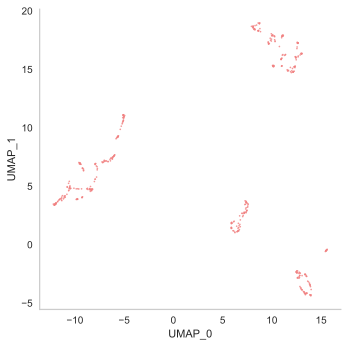

FDC.normalize (plotting): 0.34375 / 4.500s
FDC.normalize (array -> DataFrame): 0.00000 / 4.500s
FDC.normalize (total): 0.00000 / 4.500s


In [81]:

fdc = FDC(clustering_cont=Clustering('euclidean',15,0.1)
          , clustering_ord=Clustering(modified_can,15,0.1)
          , clustering_nom=Clustering('hamming',15,0.1)
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True
          )

fdc.selectFeatures(continueous=cont_list, nomial=nom_list, ordinal=ord_list)

FDC_emb_high,FDC_emb_low = fdc.normalize(data,n_neighbors=15, min_dist=0.1,cont_list=cont_list, nom_list=nom_list, ord_list=ord_list,
                  with_2d_embedding=True,
                  visual=True)

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering do K-means

In [82]:
FDC_emb_low.rename(columns={"UMAP_0": "FDC_0", "UMAP_1": "FDC_1"},inplace=True)

In [83]:
from fdc.clustering import Clustering

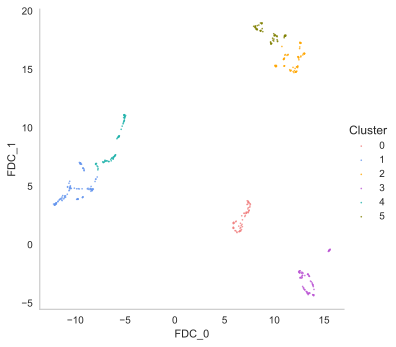

In [84]:
clustering=Clustering(FDC_emb_low,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(6)

In [85]:


### ANOVA TEST

data['Cluster']=cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  88.89 %
percentage of ordinal features having p-value less than 0.05:  100.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  81.81818181818183 %


In [86]:
silhouette_score(FDC_emb_low, cluster_list, metric='euclidean')


0.723858784652665

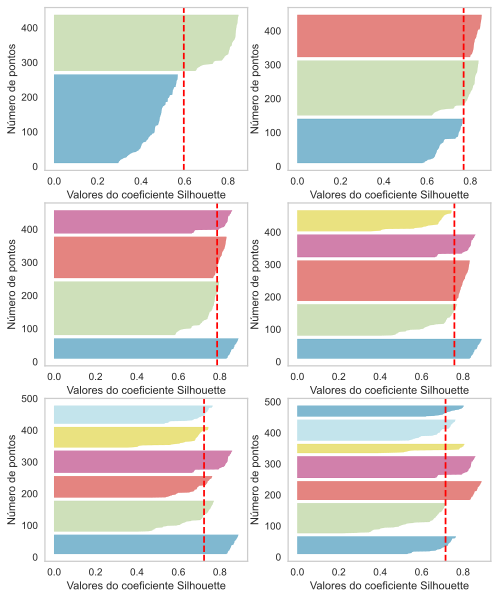

In [87]:
Silhouette_visual(FDC_emb_low)

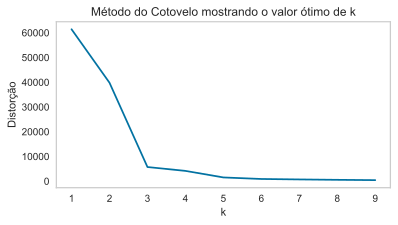

In [88]:
elbow_plot(FDC_emb_low)

In [89]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list))

2.620043626582621

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering Aglomerativo

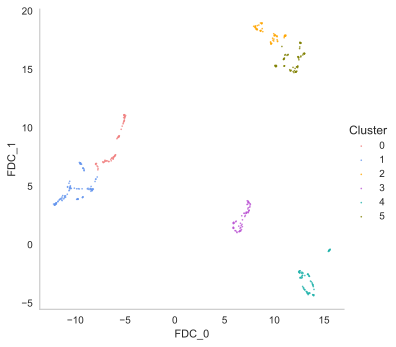

In [90]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(6,'euclidean','ward')

In [91]:

### ANOVA TEST

data['Cluster']=cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  88.89 %
percentage of ordinal features having p-value less than 0.05:  100.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  81.81818181818183 %


In [92]:
silhouette_score(FDC_emb_low, cluster_list_agglo, metric='euclidean')

0.6994628646387406

In [93]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_agglo))

0.11406379021973644

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering do DBSCAN

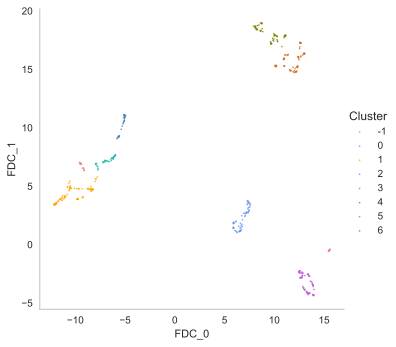

In [94]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(1.2,20)

In [95]:

### ANOVA TEST


data['Cluster']=cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  100.0 %
percentage of ordinal features having p-value less than 0.05:  100.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [96]:
#removing noise indices from the embeddings
non_noise_indices= np.where(np.array(cluster_list_dbscan)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list_dbscan= np.array(cluster_list_dbscan)[non_noise_indices]


In [97]:
silhouette_score(FDC_emb_low, cluster_list_dbscan, metric='euclidean')

0.7119151897394924

In [98]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_dbscan))

0.12302820411122294